# 01 — Kəşfedici Məlumat Analizi (EDA)

Apar — İstifadəçi Rəylərinin Təsnifatı

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
print('Train shape:', train.shape)
print('Test shape :', test.shape)

Train shape: (17769, 4)
Test shape : (4797, 3)


In [2]:
import sys
print(sys.executable)

c:\Users\Imranha\OneDrive - GoldenPay OJSC\Desktop\Apar\venv\Scripts\python.exe


In [4]:
train.head(10)

,id,feedback,tag,label
0,0,bugun 2 velosipod goturdum ikisinin de tormozu...,NaN,technical_support
1,1,sol pedalda problem var bu veloda,NaN,technical_support
2,2,Oturacağın alt-ön tərəfi çıxıb dəyişilməlidir,Other,technical_support
3,3,velospied kilidə düşmürdü,NaN,technical_support
4,4,Gprs islemir anbara getmelidi,Electrical system,technical_support
5,5,Rolu əyri gedir təkəri əyri,Handlebar,technical_support
6,6,səs salırdı...sepin üstündəki plasmas aralanmisdi,NaN,technical_support
7,7,Parking zonasindayam lakin gedişi bitire bilmirəm,Kickstand,customer_support
8,8,"ужасно глучит приложение, не могу спокойно зак...",NaN,customer_support
9,9,oturacaq sabit qalmir,NaN,technical_support


## Label Paylanması

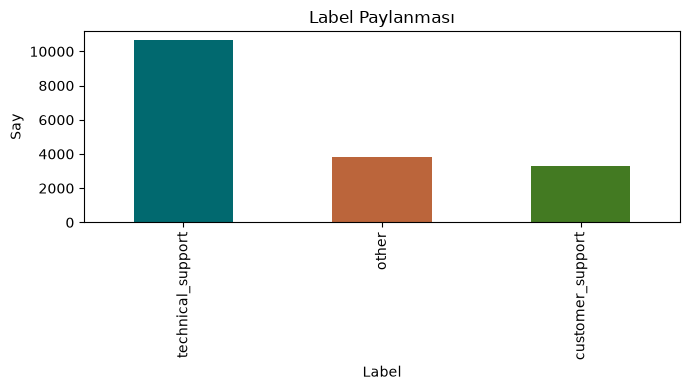

label
technical_support    59.89
other                21.39
customer_support     18.72
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
train['label'].value_counts().plot(kind='bar', ax=ax, color=['#01696f','#bb653b','#437a22'])
ax.set_title('Label Paylanması')
ax.set_xlabel('Label')
ax.set_ylabel('Say')
plt.tight_layout()
plt.show()
print(train['label'].value_counts(normalize=True).mul(100).round(2))

## Feedback Uzunluğu Analizi

In [6]:
train['feedback_len'] = train['feedback'].fillna('').apply(len)
train.groupby('label')['feedback_len'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
customer_support,3327.0,57.392546,44.337826,4.0,27.0,45.0,73.0,298.0
other,3800.0,31.036053,35.693351,1.0,9.0,19.5,39.0,270.0
technical_support,10642.0,32.015974,24.796890,2.0,17.0,25.0,39.0,291.0


## Boş (NaN) Dəyərlər

In [7]:
train.isnull().sum()

id                  0
feedback            0
tag             12504
label               0
feedback_len        0
dtype: int64

## Tag Sütununun Analizi

In [8]:
print('Tag doldurulma faizi:', train['tag'].notna().mean().round(3))
train['tag'].value_counts().head(20)

Tag doldurulma faizi: 0.296


tag
Other                 2433
Brakes                 327
Pedals                 233
Gears/transmission     215
Electrical system      200
Kickstand              196
Battery                183
Handlebar              162
Saddle                 149
Motor                  147
Chain                  147
Vandalism              145
Firmware               120
QR code                104
Rear wheel              93
Front wheel             88
Ignition                74
Lose/worn parts         63
Display                 54
Dirty                   37
Name: count, dtype: int64